12:00:31 - cmdstanpy - INFO - Chain [1] start processing
12:00:32 - cmdstanpy - INFO - Chain [1] done processing


MAE:  1938.78
RMSE: 3649.56
MAPE: 10.87%


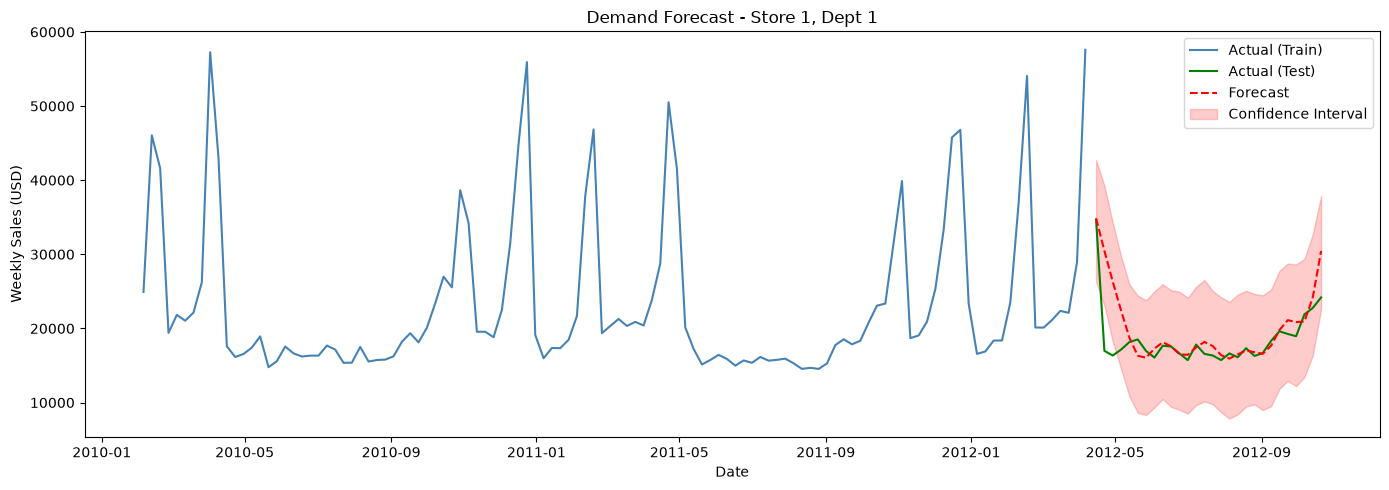

Forecast saved to outputs/forecast_output.csv


In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os

train = pd.read_csv('../data/train.csv')
features = pd.read_csv('../data/features.csv')
stores = pd.read_csv('../data/stores.csv')

df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])

df = df[df['Weekly_Sales'] > 0]

store1_dept1 = df[(df['Store'] == 1) & (df['Dept'] == 1)][['Date', 'Weekly_Sales']].copy()
store1_dept1.columns = ['ds', 'y']
store1_dept1 = store1_dept1.sort_values('ds').reset_index(drop=True)

split_index = int(len(store1_dept1) * 0.8)
train_df = store1_dept1.iloc[:split_index]
test_df = store1_dept1.iloc[split_index:]
split_date = train_df['ds'].max()

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(train_df)

future = model.make_future_dataframe(periods=len(test_df), freq='W')
forecast = model.predict(future)

forecast_trimmed = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_trimmed['ds'] = pd.to_datetime(forecast_trimmed['ds']).dt.normalize()
test_df['ds'] = pd.to_datetime(test_df['ds']).dt.normalize()

test_forecast = forecast_trimmed.merge(test_df, on='ds', how='inner')

if len(test_forecast) == 0:
    forecast_trimmed['ds_week'] = forecast_trimmed['ds'].dt.to_period('W')
    test_df['ds_week'] = test_df['ds'].dt.to_period('W')
    test_forecast = forecast_trimmed.merge(test_df, on='ds_week', how='inner')
    test_forecast['ds'] = test_forecast['ds_x']

mae = mean_absolute_error(test_forecast['y'], test_forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_forecast['y'], test_forecast['yhat']))
mape = (abs(test_forecast['y'] - test_forecast['yhat']) / test_forecast['y']).mean() * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

os.makedirs('../outputs', exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(train_df['ds'], train_df['y'], color='steelblue', label='Actual (Train)')
plt.plot(test_forecast['ds'], test_forecast['y'], color='green', label='Actual (Test)')
plt.plot(test_forecast['ds'], test_forecast['yhat'], color='red', linestyle='--', label='Forecast')
plt.fill_between(test_forecast['ds'], test_forecast['yhat_lower'], test_forecast['yhat_upper'],
                 alpha=0.2, color='red', label='Confidence Interval')
plt.title('Demand Forecast - Store 1, Dept 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/forecast_store1_dept1.png')
plt.show()

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('../outputs/forecast_output.csv', index=False)
print("Forecast saved to outputs/forecast_output.csv")

In [2]:
import os
os.environ['DYLD_LIBRARY_PATH'] = '/usr/local/opt/libomp/lib'

In [4]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def create_features(df):
    df = df.copy()
    df['week'] = df['ds'].dt.isocalendar().week.astype(int)
    df['month'] = df['ds'].dt.month
    df['quarter'] = df['ds'].dt.quarter
    df['year'] = df['ds'].dt.year
    df['lag_1'] = df['y'].shift(1)
    df['lag_4'] = df['y'].shift(4)
    df['lag_52'] = df['y'].shift(52)
    df['rolling_mean_4'] = df['y'].shift(1).rolling(4).mean()
    df['rolling_mean_12'] = df['y'].shift(1).rolling(12).mean()
    return df

store1_dept1_feat = create_features(store1_dept1.copy())
store1_dept1_feat = store1_dept1_feat.dropna()

split_idx = int(len(store1_dept1_feat) * 0.8)
train_xgb = store1_dept1_feat.iloc[:split_idx]
test_xgb = store1_dept1_feat.iloc[split_idx:]

features = ['week', 'month', 'quarter', 'year', 'lag_1', 'lag_4', 'lag_52',
            'rolling_mean_4', 'rolling_mean_12']

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(train_xgb[features], train_xgb['y'])

xgb_preds = xgb_model.predict(test_xgb[features])

xgb_mae = mean_absolute_error(test_xgb['y'], xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(test_xgb['y'], xgb_preds))
xgb_mape = (abs(test_xgb['y'] - xgb_preds) / test_xgb['y']).mean() * 100

print("XGBoost Results:")
print(f"MAE:  {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAPE: {xgb_mape:.2f}%")

XGBoost Results:
MAE:  1170.80
RMSE: 1636.94
MAPE: 5.84%


In [5]:
comparison = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost'],
    'MAE': [round(mae, 2), round(xgb_mae, 2)],
    'RMSE': [round(rmse, 2), round(xgb_rmse, 2)],
    'MAPE (%)': [round(mape, 2), round(xgb_mape, 2)]
})
comparison

,Model,MAE,RMSE,MAPE (%)
0,Prophet,1938.78,3649.56,10.87
1,XGBoost,1170.80,1636.94,5.84


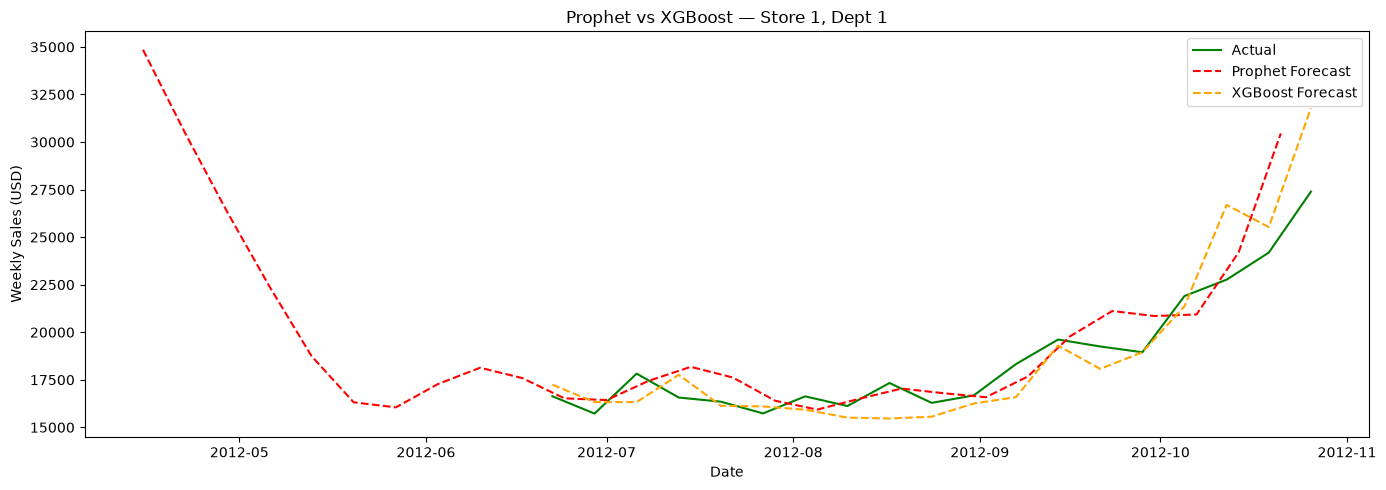

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(test_xgb['ds'], test_xgb['y'], color='green', label='Actual')
plt.plot(test_forecast['ds'], test_forecast['yhat'], color='red', linestyle='--', label='Prophet Forecast')
plt.plot(test_xgb['ds'], xgb_preds, color='orange', linestyle='--', label='XGBoost Forecast')
plt.title('Prophet vs XGBoost — Store 1, Dept 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()
